# Image Classification: Deteksi Jenis Sampah di Sekitar Kampus

### Practice Deep Learning

**Nama** : Muhammad Zaidi  
**NIM** : 4222301071

**Dataset** : trash, plastic, paper, metal, glass, cardboard  
**Metode** : Transfer Learning menggunakan MobileNetV2 sebagai pre-trained model.

**Sumber Dataset**  
https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset

---

## Tujuan

adalah menerapkan Transfer Learning untuk melakukan klasifikasi citra jenis sampah menggunakan model yang telah dilatih sebelumnya (pre-trained model), sehingga proses pelatihan menjadi lebih cepat dan menghasilkan akurasi yang baik meskipun menggunakan dataset yang relatif kecil.

1. Import Library

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np
import os

2. Download Dataset

In [3]:
# Check if kaggle.json exists in the expected location
!ls -l ~/.kaggle/kaggle.json

ls: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
from google.colab import files
import os

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

# Make a directory for Kaggle if it doesn't exist
!mkdir -p ~/.kaggle
# Move the uploaded kaggle.json to the directory
!mv kaggle.json ~/.kaggle/
# Set permissions (important for security)
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key configured successfully. You can now re-run the dataset download cell (cell m-j9iMRuL6ED).")

Saving trash_041.jpg to trash_041.jpg
User uploaded file "trash_041.jpg" with length 11043 bytes
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key configured successfully. You can now re-run the dataset download cell (cell m-j9iMRuL6ED).


In [14]:
from google.colab import files
import os

print("Please upload your 'kaggle.json' file:")
uploaded = files.upload()

# Assuming only kaggle.json is uploaded
if 'kaggle.json' in uploaded:
    # Make a directory for Kaggle if it doesn't exist
    !mkdir -p ~/.kaggle
    # Move the uploaded kaggle.json to the directory
    !mv kaggle.json ~/.kaggle/
    # Set permissions (important for security)
    !chmod 600 ~/.kaggle/kaggle.json

    print("Kaggle API key configured successfully.")
else:
    print("Error: 'kaggle.json' was not uploaded. Please ensure you upload the correct file.")

Please upload your 'kaggle.json' file:


Error: 'kaggle.json' was not uploaded. Please ensure you upload the correct file.


After successfully configuring your Kaggle API key, run the following cell to download and extract the dataset:

In [15]:
import os
from zipfile import ZipFile

# Install Kaggle library (if not already installed or upgraded)
!pip install kaggle --upgrade

# Download the dataset from Kaggle
# The dataset will be downloaded to /content/trash-type-image-dataset.zip
print("Downloading dataset...")
!kaggle datasets download -d farzadnekouei/trash-type-image-dataset -p /content/

# Path to the downloaded zip file
zip_path = "/content/trash-type-image-dataset.zip"

# Extract the contents of the zip file
print("Extracting dataset...")
with ZipFile(zip_path,'r') as zip:
    zip.extractall('/content/')

# Define the base path for the extracted dataset
dataset_path = "/content/trash-type-image-dataset"

# Optional: Clean up the downloaded zip file after extraction
!rm "/content/trash-type-image-dataset.zip"

print("Dataset downloaded and extracted successfully to:", dataset_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.8/243.8 kB 13.1 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2
Dataset URL: https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset
License(s): unknown
100% 40.9M/40.9M [00:00<00:00, 54.8MB/s]

Extracting dataset...
Dataset downloaded and extracted successfully to: /content/trash-type-image-dataset


In [4]:
# Check if the downloaded zip file exists
!ls -l /content/trash-type-image-dataset.zip

# Check if the extracted dataset directory exists and its contents
!ls -l "$dataset_path"

ls: cannot access '/content/trash-type-image-dataset.zip': No such file or directory
ls: cannot access '': No such file or directory


3. Exploratory Data Analysis (EDA)

Menampilkan jumlah gambar setiap kelas

In [17]:
import os

dataset_path = "/content/TrashType_Image_Dataset"

classes = os.listdir(dataset_path)

print("Jumlah kelas :", len(classes))
print(classes)

for c in classes:
    total = len(os.listdir(os.path.join(dataset_path,c)))
    print(f"{c} : {total} gambar")

Jumlah kelas : 6
['metal', 'glass', 'trash', 'paper', 'cardboard', 'plastic']
metal : 410 gambar
glass : 501 gambar
trash : 137 gambar
paper : 594 gambar
cardboard : 403 gambar
plastic : 482 gambar


Visualisasi jumlah gambar

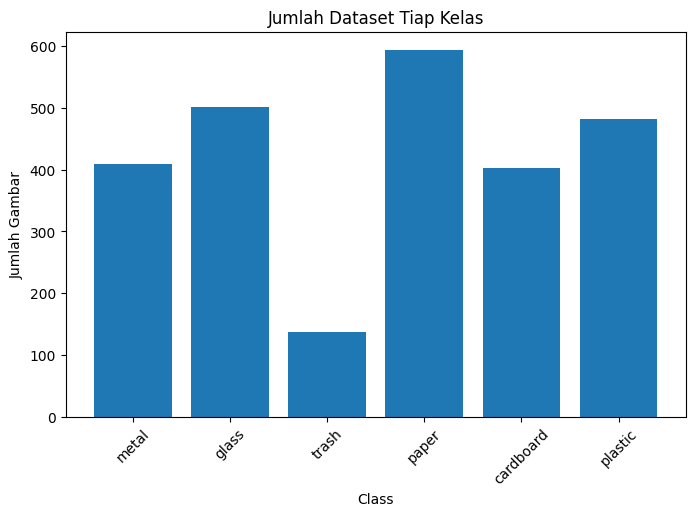

In [18]:
import matplotlib.pyplot as plt

jumlah = []

for c in classes:
    jumlah.append(len(os.listdir(os.path.join(dataset_path,c))))

plt.figure(figsize=(8,5))
plt.bar(classes,jumlah)
plt.title("Jumlah Dataset Tiap Kelas")
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=45)
plt.show()

Menampilkan contoh gambar

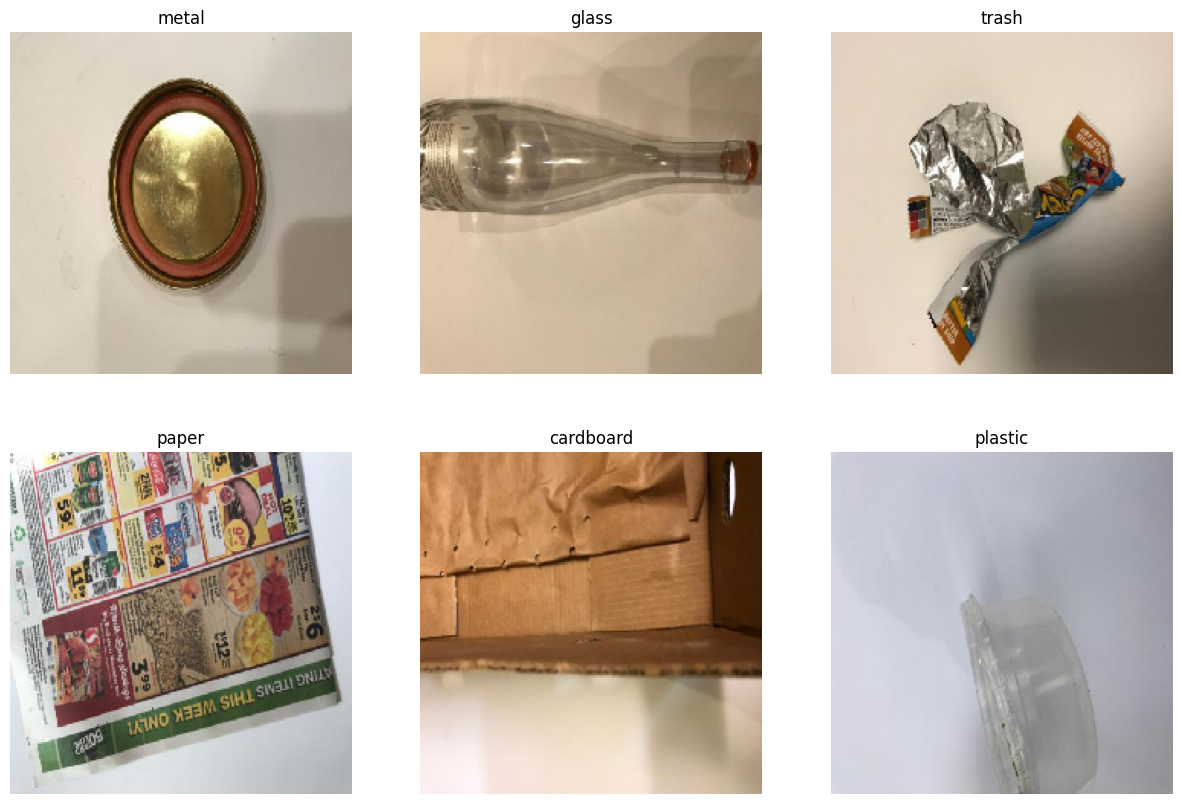

In [19]:
import random
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(15,10))

for i, kelas in enumerate(classes):

    folder = os.path.join(dataset_path,kelas)

    gambar = random.choice(os.listdir(folder))

    img = load_img(os.path.join(folder,gambar),target_size=(224,224))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(kelas)
    plt.axis("off")

plt.show()

4. Data Augmentation

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


5. Load Pre-trained Model

Menggunakan MobileNetV2.

In [21]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze layer

In [22]:
base_model.trainable = False

6. Tambahkan Classifier Baru

In [23]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [26]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Compile Model

In [28]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [29]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

7. Training

In [31]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7861 - loss: 0.5882 - val_accuracy: 0.7634 - val_loss: 0.6734
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.7984 - loss: 0.5366 - val_accuracy: 0.7555 - val_loss: 0.6302
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.8152 - loss: 0.5092 - val_accuracy: 0.7714 - val_loss: 0.6625
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.8226 - loss: 0.4814 - val_accuracy: 0.7773 - val_loss: 0.6505
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8404 - loss: 0.4565 - val_accuracy: 0.7893 - val_loss: 0.6098


8. Analisis Overfitting

Setelah training selesai jalankan:

In [32]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("Training Accuracy :",train_acc)
print("Validation Accuracy :",val_acc)

print("Training Loss :",train_loss)
print("Validation Loss :",val_loss)

Training Accuracy : 0.8404150009155273
Validation Accuracy : 0.789264440536499
Training Loss : 0.4564664661884308
Validation Loss : 0.6097925901412964


Grafik Accuracy

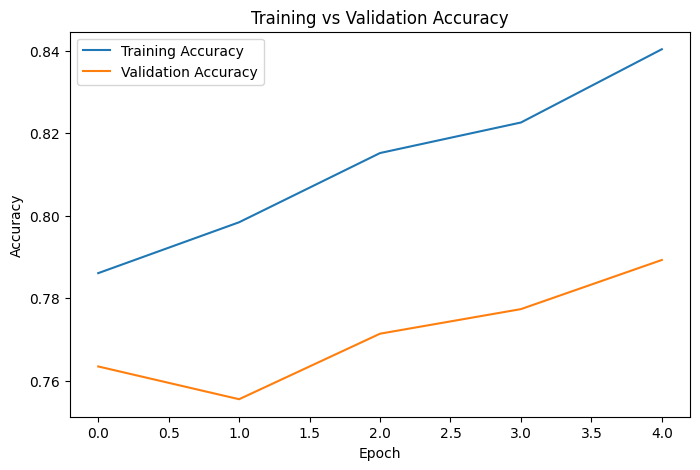

In [33]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Grafik Loss

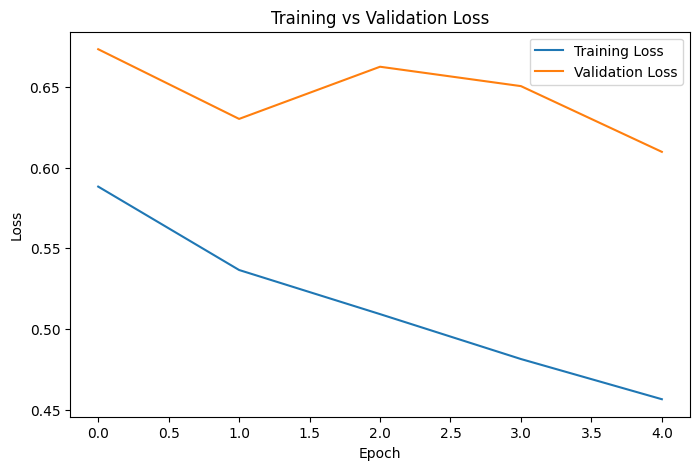

In [34]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Kesimpulan Overfitting

In [35]:
if train_acc - val_acc > 0.10:
    print("Model mengalami overfitting.")
else:
    print("Model tidak mengalami overfitting.")

Model tidak mengalami overfitting.


9. Build Final Model (Fine-Tuning)

Pada tahap pertama seluruh layer MobileNetV2 dibekukan (freeze). Setelah itu lakukan fine-tuning agar akurasi meningkat.

Membuka beberapa layer terakhir

In [36]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

Compile ulang

In [37]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Training Fine-Tuning

In [38]:
history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.6917 - loss: 0.8483 - val_accuracy: 0.7813 - val_loss: 0.6512
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - accuracy: 0.7668 - loss: 0.6320 - val_accuracy: 0.7734 - val_loss: 0.6694
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.7999 - loss: 0.5585 - val_accuracy: 0.7932 - val_loss: 0.6584
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.8172 - loss: 0.5023 - val_accuracy: 0.7594 - val_loss: 0.6903
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.8207 - loss: 0.4942 - val_accuracy: 0.8032 - val_loss: 0.6391


Evaluasi Final Model

In [39]:
loss, acc = model.evaluate(validation_generator)

print("Final Loss :",loss)
print("Final Accuracy :",acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.7654 - loss: 0.6601
Final Loss : 0.6600590944290161
Final Accuracy : 0.7654075622558594


Visualisasi Hasil Fine-Tuning

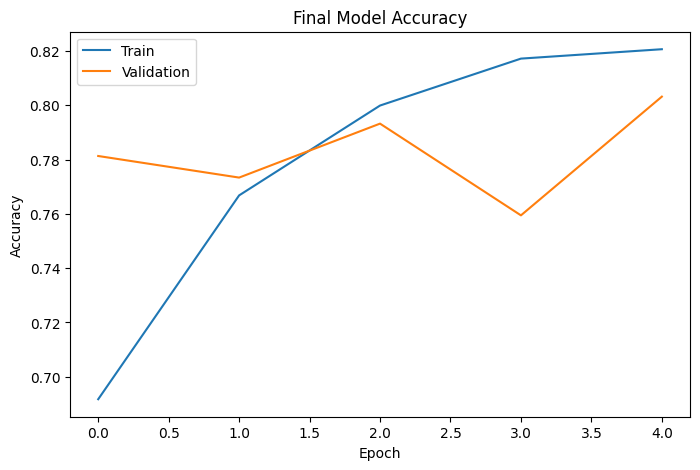

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history_finetune.history['accuracy'],label='Train')
plt.plot(history_finetune.history['val_accuracy'],label='Validation')

plt.title("Final Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

10. Visualisasi Accuracy

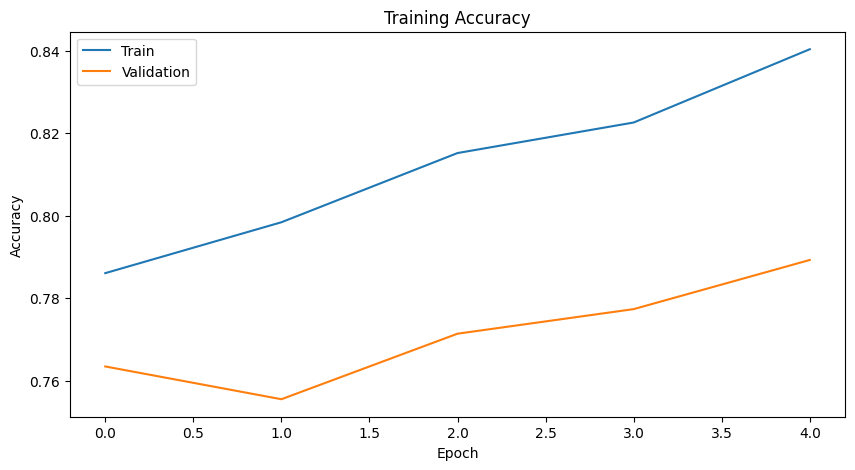

In [41]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()

plt.show()

11. Visualisasi Loss

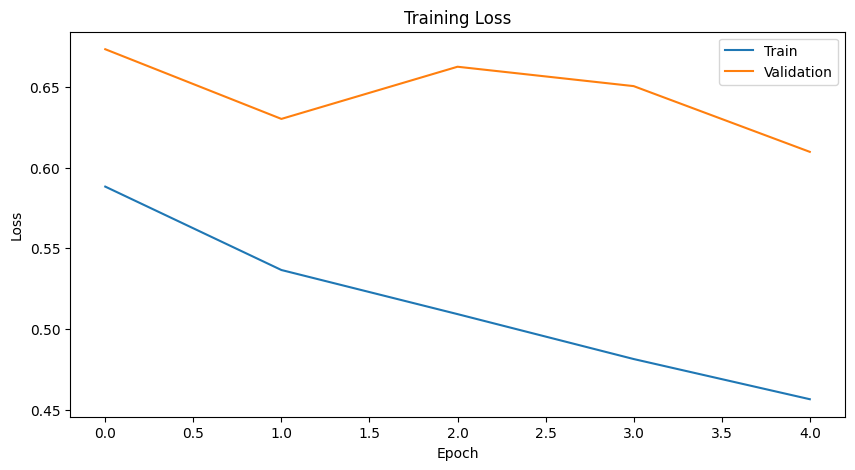

In [42]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

plt.show()

12. Evaluasi Model

In [43]:
loss, acc = model.evaluate(validation_generator)

print("Loss :",loss)
print("Accuracy :",acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.7813 - loss: 0.6649
Loss : 0.6649246215820312
Accuracy : 0.781312108039856


13. Prediksi Gambar Baru

Upload gambar

In [45]:
from google.colab import files

uploaded = files.upload()

Saving cardboard_258.jpg to cardboard_258.jpg


Load gambar

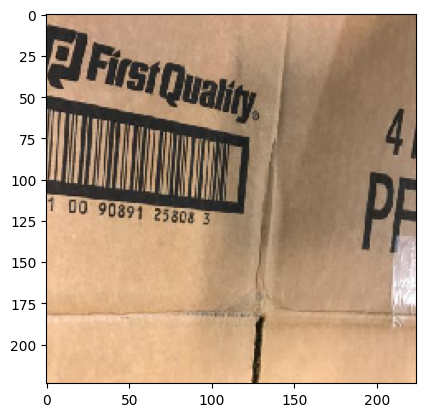

In [46]:
from tensorflow.keras.preprocessing import image

img = image.load_img(
    list(uploaded.keys())[0],
    target_size=(224,224)
)

plt.imshow(img)
plt.show()

Prediksi

In [47]:
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array,axis=0)

img_array = img_array/255.

prediction = model.predict(img_array)

classes = list(train_generator.class_indices.keys())

print("Prediction :",classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction : cardboard


14. Simpan Model

In [48]:
model.save("transfer_learning_trash_classifier.h5")

Kesimpulan

Transfer Learning memanfaatkan model yang telah dilatih sebelumnya sehingga proses pelatihan menjadi lebih cepat, membutuhkan data yang lebih sedikit, dan memberikan akurasi yang lebih baik dibandingkan membangun model dari awal. Pada praktik ini digunakan MobileNetV2 sebagai model pre-trained untuk mengklasifikasikan berbagai jenis sampah sesuai dengan materi Week 13.